Conditions
* 10: 2 hour GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 11: 15 min. GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 12: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, lots of nuclei
* 13: no-accessibility control
* 14: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, 500k nuclei

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile, load_processed

In [4]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
bam_dir = config.processed_data_dir / "20240831_GpC_CpG_crosstalk_demuxed"
barcodes = [10, 11, 12, 13]

# NOTE: Match window sizes set in third_party_data.ipynb
window_size = 1500
ctcf_on_target_window_size = 200
motifs = ["A,0", "GCH,1", "WCG,1"]
mod_prob_thresh = 0.95
smoothing = 25
n_cores = 10

y_lim = (-0.01, 0.55)

In [147]:
for barcode in barcodes:
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    parse_bam.pileup(
        input_file=bam_file,
        output_name=f"pileup.{output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_bed_file,
        motifs=motifs,
        thresh=mod_prob_thresh,
        window_size=window_size,
        cores=n_cores,
        override_checks=True
    )
    parse_bam.extract(
        input_file=bam_file,
        output_name=f"extract.{bam_file.stem}.gm12878_ctcf.on_target",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_on_target_bed_file,
        motifs=motifs,
        thresh=None, # No thresholding at extract time
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )

Allocating requested 10 cores.
Modification threshold of 0.95 will be treated as coming from range 0-1.


[E::hts_open_format] Failed to open file "/Users/jeremy/devspace/multimodal-dimelo/data/processed/20240831_GpC_CpG_crosstalk_demuxed/barcode10.bam" : No such file or directory


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode10.bam   0% | 00:00<?

          |    0%

Error! file not found: /Users/jeremy/devspace/multimodal-dimelo/data/processed/20240831_GpC_CpG_crosstalk_demuxed/barcode10.bam



CalledProcessError: Command '['modkit', 'pileup', PosixPath('/Users/jeremy/devspace/multimodal-dimelo/data/processed/20240831_GpC_CpG_crosstalk_demuxed/barcode10.bam'), PosixPath('/Users/jeremy/devspace/multimodal-dimelo/data/processed/pileup.barcode10.gm12878_ctcf_motif_intersect_chip.top3k/pileup.bed'), '--include-bed', '/Users/jeremy/devspace/multimodal-dimelo/data/processed/pileup.barcode10.gm12878_ctcf_motif_intersect_chip.top3k/regions.processed.bed', '--motif', 'A', '0', '--motif', 'GCH', '1', '--motif', 'WCG', '1', '--ref', PosixPath('/Users/jeremy/devspace/multimodal-dimelo/data/raw/chm13v2.0.fa'), '--filter-threshold', '0', '--mod-thresholds', 'a:0.95', '--mod-thresholds', 'Y:0.95', '--mod-thresholds', 'm:0.95', '--mod-thresholds', 'Z:0.95', '--mod-thresholds', 'm:0.95', '--mod-thresholds', 'Z:0.95', '--threads', '10']' returned non-zero exit status 1.

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

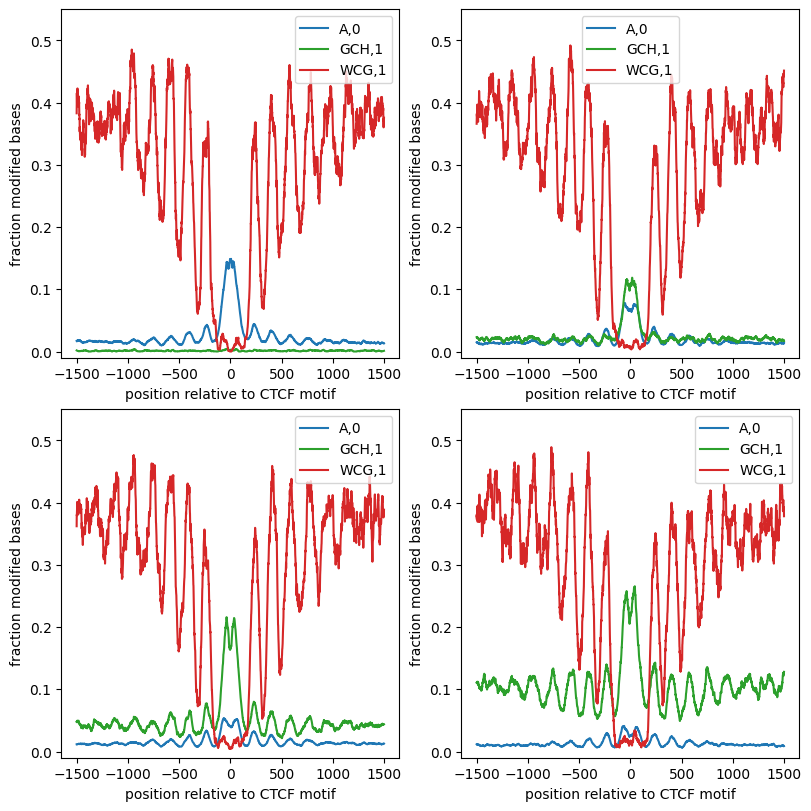

In [ ]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{output_id}" / "pileup.sorted.bed.gz",
        regions=ctcf_bed_file,
        motifs=motifs,
        window_size=window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
    ax.set_xlabel("position relative to CTCF motif")
    ax.set_ylim(y_lim)
    ax.legend(title="")

plt.savefig(config.figure_dir / "crosstalk.plot_enrichment_profile.svg")
plt.show()
plt.close()

# Supplemental Figures

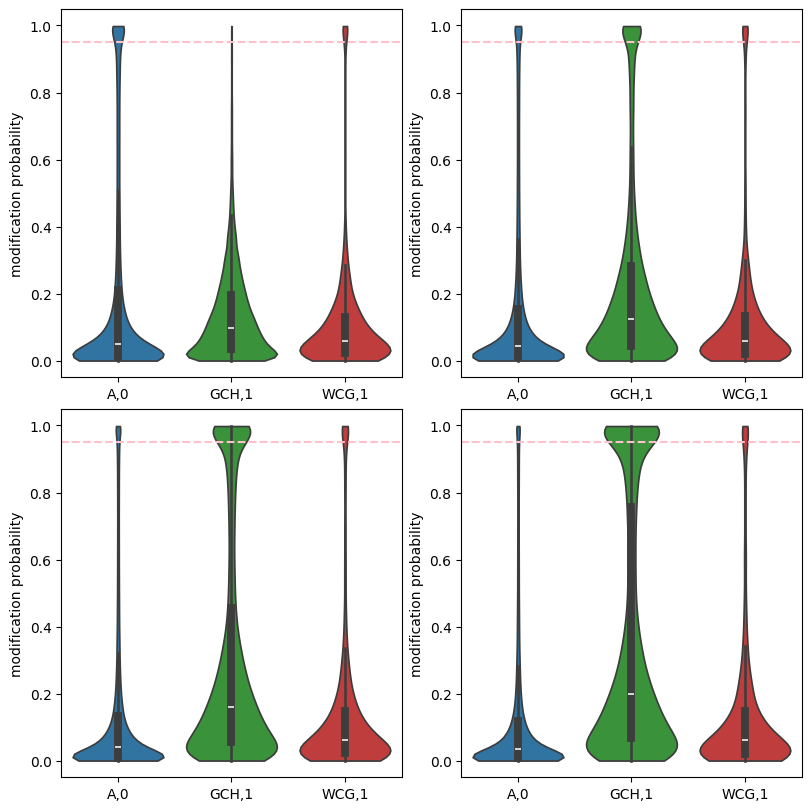

In [ ]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    on_target_motif_mod_vector_dict = {}
    file_path = config.processed_data_dir / f"extract.{bam_file.stem}.gm12878_ctcf.on_target" / "reads.combined_basemods.h5"
    for motif in motifs:
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=file_path,
            motifs=[motif],
            regions=ctcf_on_target_bed_file,
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        # TODO: Does it matter if I sample without replacement here?
        # on_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)
        on_target_motif_mod_vector_dict[motif] = mod_vector
    sns.violinplot(
        on_target_motif_mod_vector_dict, cut=0,
        palette=plotting.default_palette_map, # height=2.8, aspect=1,
        ax=ax
    )
    ax.axhline(mod_prob_thresh, linestyle="--", color="pink")
    ax.set_ylabel("modification probability")
    # plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
    # plt.title("On-target modification\nprobability distributions")

plt.savefig(config.figure_dir / "crosstalk.mod_probs.on_target.svg")
plt.show()
plt.close()

In [1]:
from collections import defaultdict
from scipy import stats, special
from scipy.spatial import distance

In [5]:
# Load read extractions
# TODO: should only do loading one time, before plotting or performing tests
motif_mod_vectors = defaultdict(list)
for motif in motifs:
    for barcode in [13, 11, 10, 12]:
        bam_file = bam_dir / f"barcode{barcode}.bam"
        file_path = config.processed_data_dir / f"extract.{bam_file.stem}.gm12878_ctcf.on_target" / "reads.combined_basemods.h5"
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=file_path,
            motifs=[motif],
            regions=ctcf_on_target_bed_file,
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        motif_mod_vectors[motif].append(mod_vector)

In [ ]:
# TODO: This version takes WAY too long for no apparent reason. I refuse to sit here waiting that long.
# # Load modfracs for each CTCF site
# # TODO: should only do loading one time, before plotting or performing tests
# motif_ctcf_modfracs = defaultdict(list)
# for motif in motifs:
#     for barcode in [13, 11, 10, 12]:
#         bam_file = bam_dir / f"barcode{barcode}.bam"
#         output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
#         site_tuples = load_processed.regions_to_list(
#             load_processed.pileup_counts_from_bedmethyl,
#             bedmethyl_file = config.processed_data_dir / f"pileup.{output_id}" / "pileup.sorted.bed.gz",
#             regions=ctcf_bed_file,
#             motif=motif,
#             window_size=window_size,
#             quiet=False
#         )
#         motif_ctcf_modfracs[motif].append([modified_bases / total_bases for modified_bases, total_bases in site_tuples])

In [6]:
from io import BytesIO
import subprocess
modkit_exe = "/Users/jeremy/devspace/cargo_local/bin/modkit"

import pandas as pd

In [221]:
# Load modfracs for each CTCF site. THIS ONLY WORKS FOR As RIGHT NOW
# TODO: This is probably doable with just python csv, not pandas, but I'm lazy
# TODO: should only do loading one time, before plotting or performing tests
ctcf_a_modfracs = []
for barcode in [13, 11, 10, 12]:
    bam_file = bam_dir / f"barcode{barcode}.bam"
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    pileup_file = config.processed_data_dir / f"pileup.{output_id}" / "pileup.sorted.bed.gz"
    modkit_output = subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {ctcf_on_target_bed_file} -o -", shell=True, capture_output=True)
    ctcf_a_modfracs.append(pd.read_csv(BytesIO(modkit_output.stdout), sep="\t")["percent_a"])

KS test

In [7]:
for motif in ["A,0", "WCG,1"]:
    print("*" * 20)
    print(motif)
    mod_vectors = motif_mod_vectors[motif]
    for i in range(1,4):
        stat, pval = stats.ks_2samp(mod_vectors[0], mod_vectors[i])
        print(f"kstest(0,{i}): stat={stat:.2}, pval={pval:.2}")

********************
A,0
kstest(0,1): stat=0.041, pval=8e-194
kstest(0,2): stat=0.063, pval=0.0
kstest(0,3): stat=0.084, pval=0.0
********************
WCG,1
kstest(0,1): stat=0.018, pval=0.05
kstest(0,2): stat=0.043, pval=7.8e-11
kstest(0,3): stat=0.057, pval=1.5e-15


In [60]:
motif_mod_vectors[motif]

[array([0.02148, 0.0918 , 0.0918 , ..., 0.1113 , 0.1621 , 0.4043 ],
       shape=(10743,), dtype=float16),
 array([0.0293, 0.0918, 0.0801, ..., 0.2637, 0.1504, 0.1699],
       shape=(11205,), dtype=float16),
 array([0.06445 , 0.009766, 0.1113  , ..., 0.01367 , 0.0762  , 0.994   ],
       shape=(15875,), dtype=float16),
 array([0.009766, 0.02148 , 0.02148 , ..., 0.01758 , 0.1309  , 0.00586 ],
       shape=(10659,), dtype=float16)]

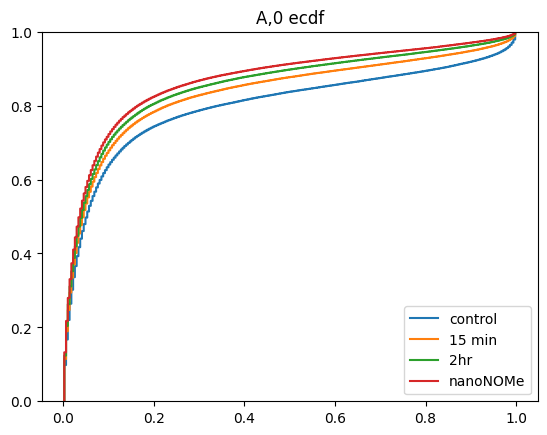

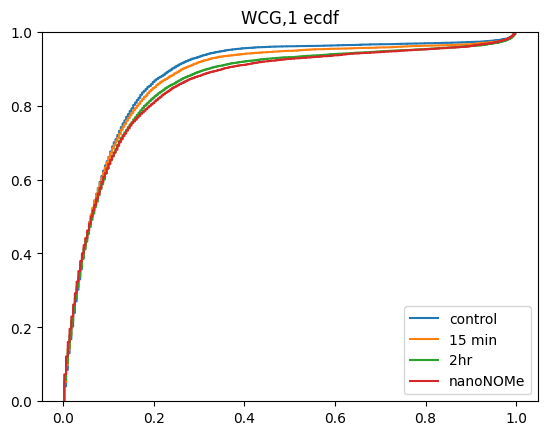

In [66]:
labels = ["control", "15 min", "2hr", "nanoNOMe"]
for motif in ["A,0", "WCG,1"]:
    for i in range(4):
        plt.ecdf(motif_mod_vectors[motif][i], label=labels[i])
    plt.title(f"{motif} ecdf")
    plt.legend(loc="lower right")
    plt.show()

Setting up for probability distribution comparisons

In [8]:
# 256 equally spaced values between 0 and 1, with standard correction
mod_prob_pmf_values = (np.linspace(0, 1, 257) - ((0 + 0.5) / 256))[1:]

In [9]:
def mod_prob_pmf(mod_prob_vector: np.ndarray) -> np.ndarray:
    """
    Returns a vector containing PMF corresponding to the given mod prob vector.

    Guaranteed to return a normalized 256 element array.
    """
    hist, _ = np.histogram(mod_prob_vector, bins=256, range=(0, 1))
    return(hist / np.sum(hist))


In [10]:
motif_mod_pmfs = {motif: [mod_prob_pmf(v) for v in mod_vecs] for motif, mod_vecs in motif_mod_vectors.items()}

KL divergence

Note that this doesn't reliably work when there are values that are 0

In [404]:
for motif in ["A,0", "WCG,1"]:
    print("*" * 20)
    print(motif)
    mod_pmfs = motif_mod_pmfs[motif]
    entropy = stats.entropy(mod_pmfs[0])
    print(f"entropy(0): {entropy}")
    for i in range(1,4):
        kl_div = stats.entropy(mod_pmfs[0], mod_pmfs[i])
        print(f"kl_div(0,{i}): {kl_div:.3}")

********************
A,0
entropy(0): 4.389758784988006
kl_div(0,1): 0.0117
kl_div(0,2): 0.0283
kl_div(0,3): 0.0476
********************
WCG,1
entropy(0): 4.217301931171641
kl_div(0,1): inf
kl_div(0,2): inf
kl_div(0,3): inf


Jensen-Shannon distance

In [405]:
# TODO: Should I be reporting the divergence, which is this quantity squared?
for motif in ["A,0", "WCG,1"]:
    print("*" * 20)
    print(motif)
    mod_pmfs = motif_mod_pmfs[motif]
    for i in range(4):
        js_div = distance.jensenshannon(mod_pmfs[0], mod_pmfs[i])
        print(f"js_div(0,{i}): {js_div:.3}")

********************
A,0
js_div(0,0): 0.0
js_div(0,1): 0.0523
js_div(0,2): 0.0794
js_div(0,3): 0.101
********************
WCG,1
js_div(0,0): 0.0
js_div(0,1): 0.0935
js_div(0,2): 0.103
js_div(0,3): 0.127


Wasserstein distance

In [11]:
for motif in ["A,0", "WCG,1"]:
    print("*" * 20)
    print(motif)
    mod_vectors = motif_mod_vectors[motif]
    for i in range(4):
        wd = stats.wasserstein_distance(mod_vectors[0], mod_vectors[i])
        print(f"wd_(0,{i}): {wd:.4}")

********************
A,0
wd_(0,0): 0.0
wd_(0,1): 0.03642
wd_(0,2): 0.05527
wd_(0,3): 0.0701
********************
WCG,1
wd_(0,0): 0.0
wd_(0,1): 0.009985
wd_(0,2): 0.02467
wd_(0,3): 0.02906


Wasserstein bootstrap

In [37]:
bootstrap_results = defaultdict(list)
for motif in ["A,0", "WCG,1"]:
    for i in range(1, 4):
        # TODO: using method "basic" because "BCa" crashed the kernel. Is this reasonable?
        data = (motif_mod_vectors[motif][0], motif_mod_vectors[motif][i])
        bootstrap_result = stats.bootstrap(data, stats.wasserstein_distance, vectorized=False, rng=42, n_resamples=1000, method="basic")
        bootstrap_results[motif].append(bootstrap_result)

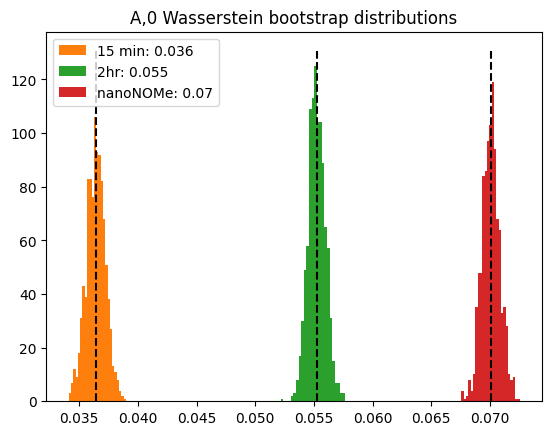

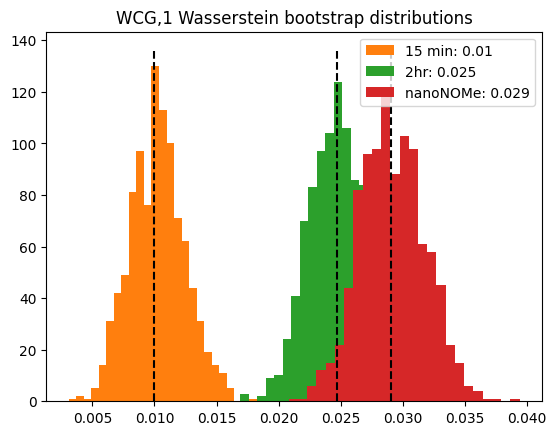

In [38]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = ["control", "15 min", "2hr", "nanoNOMe"]
for motif in ["A,0", "WCG,1"]:
    plt.figure()
    mod_vectors = motif_mod_vectors[motif]
    wds = []
    for i in range(1,4):
        wd = stats.wasserstein_distance(mod_vectors[0], mod_vectors[i])
        plt.hist(bootstrap_results[motif][i-1].bootstrap_distribution, bins=25, label=f"{labels[i]}: {wd:.2}", color=colors[i])
        wds.append(wd)
    y_min, y_max = plt.ylim()
    plt.vlines(wds, y_min, y_max, color="k", linestyle="--")
    plt.title(f"{motif} Wasserstein bootstrap distributions")
    plt.legend()
    plt.show()
    plt.close()

Should the following plots only show adjacent comparisons? The far away comparison is kind of useless...

In [53]:
bootstrap_results = defaultdict(list)
bootstrap_labels = defaultdict(list)
def wassersten_difference(control, v0, v1):
    return stats.wasserstein_distance(control, v0) - stats.wasserstein_distance(control, v1)
for motif in ["A,0", "WCG,1"]:
    for i in range(1, 4):
        for j in range(i+1,4):
            # TODO: using method "basic" because "BCa" crashed the kernel. Is this reasonable?
            data = (motif_mod_vectors[motif][0], motif_mod_vectors[motif][i], motif_mod_vectors[motif][j])
            bootstrap_result = stats.bootstrap(data, wassersten_difference, vectorized=False, rng=42, n_resamples=1000, method="basic")
            bootstrap_results[motif].append(bootstrap_result)
            bootstrap_labels[motif].append(f"{labels[i]} vs. {labels[j]}")

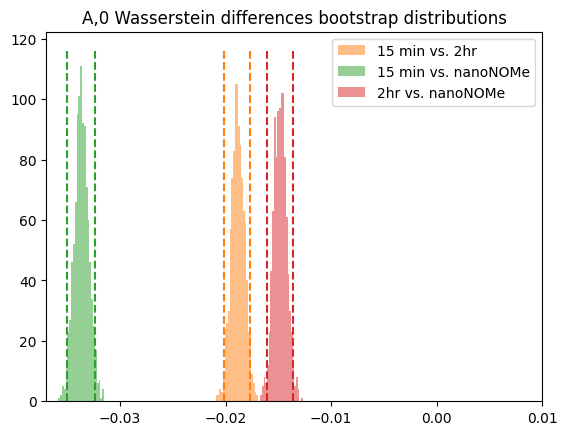

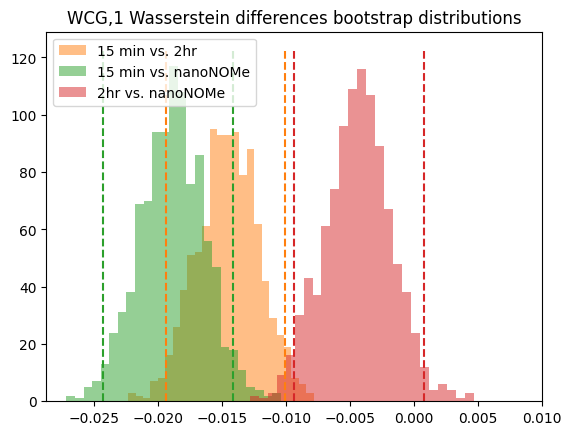

In [ ]:
colors = ["tab:orange", "tab:green", "tab:red"]
# labels = ["control", "15 min", "2hr", "nanoNOMe"]
for motif in ["A,0", "WCG,1"]:
    plt.figure()
    # mod_vectors = motif_mod_vectors[motif]
    # wds = []
    for label, result, color in zip(bootstrap_labels[motif], bootstrap_results[motif], colors):
        plt.hist(result.bootstrap_distribution, bins=25, label=label, color=color, alpha=0.5)
    y_min, y_max = plt.ylim()
    for result, color in zip(bootstrap_results[motif], colors):
        plt.vlines(result.confidence_interval, y_min, y_max, color=color, linestyle="--")
    plt.title(f"{motif} Wasserstein differences bootstrap distributions")
    plt.xlim((None, 0.01))
    plt.legend()
    plt.show()
    plt.close()

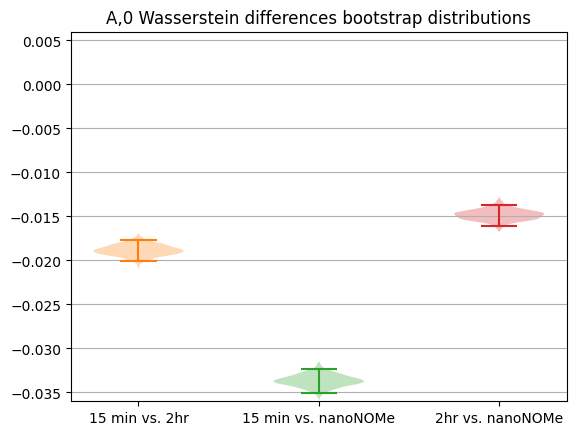

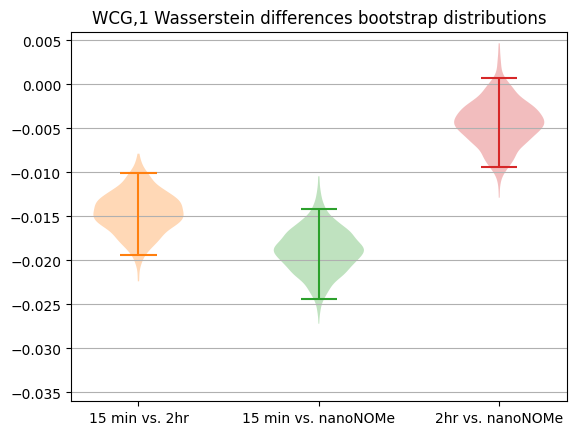

In [113]:
colors = ["tab:orange", "tab:green", "tab:red"]
# labels = ["control", "15 min", "2hr", "nanoNOMe"]
for motif in ["A,0", "WCG,1"]:
    plt.figure()
    # mod_vectors = motif_mod_vectors[motif]
    # wds = []
    for i, (label, result, color) in enumerate(zip(bootstrap_labels[motif], bootstrap_results[motif], colors)):
        violin_parts = plt.violinplot(result.bootstrap_distribution, positions=[i], showextrema=False)
        violin_parts["bodies"][0].set_facecolor(color)
        plt.hlines(result.confidence_interval, i-0.1, i+0.1, colors=color)
        plt.vlines(i, result.confidence_interval.low, result.confidence_interval.high, colors=color)
    # y_min, y_max = plt.ylim()
    # for result, color in zip(bootstrap_results[motif], colors):
    #     plt.vlines(result.confidence_interval, y_min, y_max, color=color, linestyle="--")
    plt.title(f"{motif} Wasserstein differences bootstrap distributions")
    plt.ylim((-.036, 0.006))
    plt.grid(axis="y")
    plt.xticks(range(3), labels=bootstrap_labels[motif])
    plt.show()
    plt.close()

Plots for justification

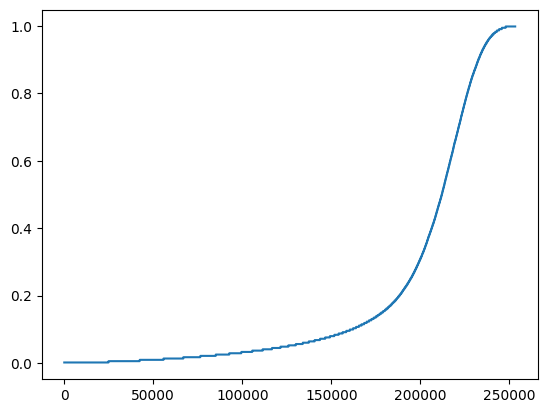

In [ ]:
plt.plot(np.sort(motif_mod_vectors["A,0"][0]))

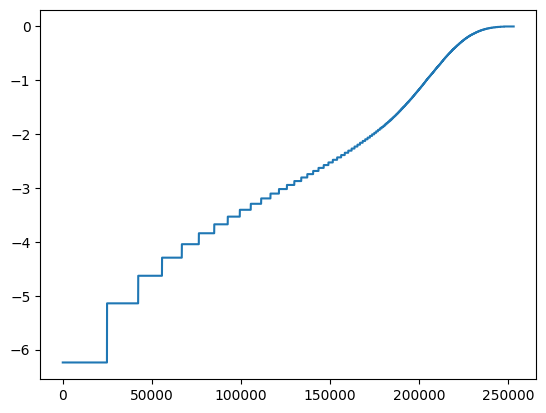

In [ ]:
plt.plot(np.sort(np.log(motif_mod_vectors["A,0"][0])))

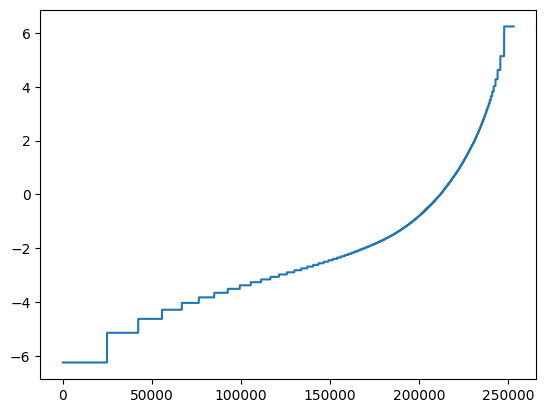

In [ ]:
plt.plot(np.log(np.sort(motif_mod_vectors["A,0"][0])) - np.log(1 - np.sort(motif_mod_vectors["A,0"][0])))

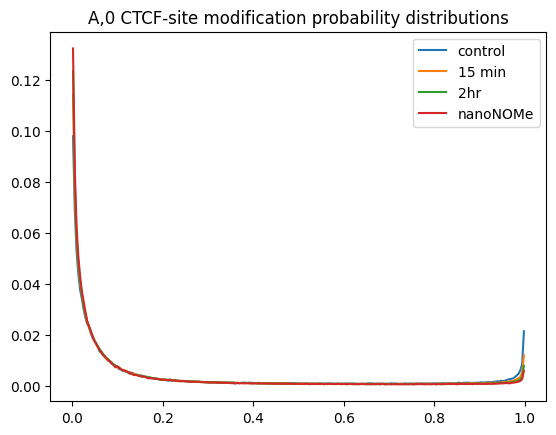

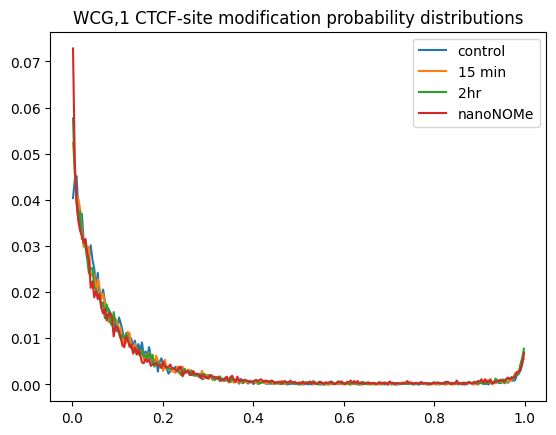

In [56]:
labels = ["control", "15 min", "2hr", "nanoNOMe"]
for motif in ["A,0", "WCG,1"]:
    for y, label in zip(motif_mod_pmfs[motif], labels):
        plt.plot(mod_prob_pmf_values, y, label=label)
    plt.title(f"{motif} CTCF-site modification probability distributions")
    plt.legend()
    plt.show()
    plt.close()